# Notebook 1 — Base Model: Modified EEGNet

**EEG-based Parkinson's Disease Detection using Modified EEGNet**

- **Dataset**: OpenNeuro ds004584 (preprocessed)
- **Input**: Preprocessed EEG epochs shaped `(N, C, T)` where:
  - N = number of epochs
  - C = number of channels (common channels across subjects)
  - T = 500 samples (2s × 250Hz)
- **Output**: Binary classification `PD vs Control`
- **Data Split**: Subject-wise (70% train, 15% val, 15% test)

> **Note**: Data is pre-split by subject in preprocessing to prevent data leakage.

In [8]:
# ===== Imports =====
import os
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Optional: EEG preprocessing (use if you load raw EEG here)
# import mne

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

def set_seed(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


Using device: cuda


In [9]:
# ===== Config =====
@dataclass
class Config:
    # Data paths (relative to this notebook in models/ folder)
    data_dir: str = "../data/processed/ds004584"
    
    # Model parameters (will be set dynamically after loading data)
    n_channels: int = 63      # Will be updated based on actual data
    n_classes: int = 2        # Binary: PD (1) vs Control (0)
    sampling_rate: int = 250  # From preprocessing
    epoch_seconds: float = 2.0
    n_samples: int = 500      # 2s × 250Hz

    # Training hyperparameters
    batch_size: int = 64
    lr: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 2
    patience: int = 10        # Early stopping patience

cfg = Config()
print(f"Data directory: {cfg.data_dir}")

Data directory: ../data/processed/ds004584


## Data Loading

The preprocessing notebook (`preprocessing/preprocess_ds004584.ipynb`) creates:
- `train.npz`, `val.npz`, `test.npz` - Subject-wise split data
- `norm_params.npz` - Normalization parameters
- `channels.json` - Channel names used

Each `.npz` file contains:
- `X`: float32 array `(N, C, T)` - Normalized EEG epochs
- `y`: int labels `(N,)` - 0=Control, 1=PD
- `subject_id`: `(N,)` - Subject ID for each epoch

In [10]:
# ===== Load preprocessed data =====
def load_split(data_dir: str, split: str):
    """Load a data split (train/val/test) from .npz file."""
    path = Path(data_dir) / f"{split}.npz"
    if not path.exists():
        raise FileNotFoundError(
            f"Expected preprocessed data at {path}.\n"
            "Run preprocessing/preprocess_ds004584.ipynb first to generate the data."
        )
    data = np.load(path, allow_pickle=True)
    X = data["X"].astype(np.float32)  # (N, C, T)
    y = data["y"].astype(np.int64)    # (N,)
    subject_id = data["subject_id"] if "subject_id" in data.files else None
    return X, y, subject_id

# Load all splits
print("Loading preprocessed data...")
X_train, y_train, sid_train = load_split(cfg.data_dir, "train")
X_val, y_val, sid_val = load_split(cfg.data_dir, "val")
X_test, y_test, sid_test = load_split(cfg.data_dir, "test")

# Update config with actual dimensions
cfg.n_channels = X_train.shape[1]
cfg.n_samples = X_train.shape[2]

print(f"\n{'='*50}")
print("DATASET LOADED")
print(f"{'='*50}")
print(f"Train: {X_train.shape} | PD: {(y_train==1).sum()}, Control: {(y_train==0).sum()}")
print(f"Val:   {X_val.shape} | PD: {(y_val==1).sum()}, Control: {(y_val==0).sum()}")
print(f"Test:  {X_test.shape} | PD: {(y_test==1).sum()}, Control: {(y_test==0).sum()}")
print(f"\nChannels: {cfg.n_channels}, Samples: {cfg.n_samples}")

Loading preprocessed data...

DATASET LOADED
Train: (16255, 60, 500) | PD: 10576, Control: 5679
Val:   (3668, 60, 500) | PD: 2429, Control: 1239
Test:  (3767, 60, 500) | PD: 2432, Control: 1335

Channels: 60, Samples: 500


In [11]:
# ===== PyTorch Dataset and DataLoaders =====
class EEGDataset(Dataset):
    """PyTorch Dataset for EEG epochs."""
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)  # (N, C, T)
        self.y = torch.from_numpy(y)  # (N,)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = EEGDataset(X_train, y_train)
val_dataset = EEGDataset(X_val, y_val)
test_dataset = EEGDataset(X_test, y_test)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 254
Val batches: 58
Test batches: 59


## Model: Modified EEGNet

EEGNet uses **depthwise + separable convolutions** (very lightweight) and is popular for EEG classification.

You can tune:
- temporal kernel length
- depth multiplier
- number of filters
- dropout


In [12]:
# ===== Modified EEGNet (PyTorch) =====
class SeparableConv2d(nn.Module):
    """Depthwise separable convolution: depthwise -> pointwise."""
    def __init__(self, in_ch, out_ch, kernel_size, padding=(0,0), bias=False):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size=kernel_size, 
                                   padding=padding, groups=in_ch, bias=bias)
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=(1,1), bias=bias)
    
    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class EEGNetModified(nn.Module):
    """
    Modified EEGNet for EEG classification.
    
    Architecture:
    1. Temporal convolution (learns frequency filters)
    2. Depthwise convolution (learns spatial filters per channel)
    3. Separable convolution (combines temporal-spatial features)
    4. Classifier head
    
    Args:
        n_channels: Number of EEG channels
        n_classes: Number of output classes
        T: Number of time samples per epoch
        F1: Number of temporal filters
        D: Depth multiplier for depthwise conv
        F2: Number of pointwise filters
        kern_len: Temporal kernel length (related to sampling rate)
        dropout: Dropout probability
    """
    def __init__(self, n_channels, n_classes, T, F1=8, D=2, F2=16, kern_len=64, dropout=0.5):
        super().__init__()
        
        # Block 1: Temporal convolution
        # Input: (B, 1, C, T) -> learns F1 frequency filters
        self.temporal_conv = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kern_len), padding=(0, kern_len//2), bias=False),
            nn.BatchNorm2d(F1)
        )
        
        # Block 2: Depthwise convolution across channels
        # Learns D spatial filters per temporal filter
        self.depthwise_conv = nn.Sequential(
            nn.Conv2d(F1, F1*D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout)
        )
        
        # Block 3: Separable convolution for temporal refinement
        self.separable_conv = nn.Sequential(
            SeparableConv2d(F1*D, F2, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )
        
        # Compute flattened feature dimension
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, T)
            out = self.separable_conv(self.depthwise_conv(self.temporal_conv(dummy)))
            self.feat_dim = out.view(1, -1).shape[1]
        
        # Classifier head
        self.classifier = nn.Linear(self.feat_dim, n_classes)
        
        # Confidence head (for error-correction stage)
        self.conf_head = nn.Linear(self.feat_dim, 1)

    def forward(self, x, return_features=False):
        """
        Forward pass.
        
        Args:
            x: Input tensor (B, C, T)
            return_features: If True, also return intermediate features
            
        Returns:
            logits: Class logits (B, n_classes)
            conf: Confidence score (B, 1) - only if return_features=True
            feats: Flattened features (B, feat_dim) - only if return_features=True
        """
        x = x.unsqueeze(1)  # (B, C, T) -> (B, 1, C, T)
        x = self.temporal_conv(x)
        x = self.depthwise_conv(x)
        x = self.separable_conv(x)
        feats = x.flatten(1)
        
        logits = self.classifier(feats)
        
        if return_features:
            conf = torch.sigmoid(self.conf_head(feats))
            return logits, conf, feats
        return logits


# Create model
model = EEGNetModified(
    n_channels=cfg.n_channels,
    n_classes=cfg.n_classes,
    T=cfg.n_samples
).to(DEVICE)

# Print model summary
print(f"Model: EEGNetModified")
print(f"Input shape: ({cfg.batch_size}, {cfg.n_channels}, {cfg.n_samples})")
print(f"Feature dimension: {model.feat_dim}")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model: EEGNetModified
Input shape: (64, 60, 500)
Feature dimension: 240
Total parameters: 2,787
Trainable parameters: 2,787


In [13]:
# ===== Training & Evaluation utilities =====
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(1, len(loader))

def eval_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            y_true.append(yb.numpy())
            y_pred.append(pred)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    return acc, f1, cm, y_true, y_pred


## Training Loop

Training with:
- **Optimizer**: AdamW with weight decay
- **Loss**: Cross-entropy
- **Early stopping**: Based on validation F1 score
- **Best model**: Saved based on validation performance

Note: Data is already split by subject in preprocessing (no CV needed here).

In [14]:
# ===== Training Loop =====
optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

# Training history
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_val_f1 = -1
best_model_state = None
patience_counter = 0

print("=" * 60)
print("TRAINING STARTED")
print("=" * 60)

for epoch in range(1, cfg.epochs + 1):
    # === Training ===
    model.train()
    train_loss = 0.0
    train_preds, train_labels = [], []
    
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        train_labels.extend(yb.cpu().numpy())
    
    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds)
    
    # === Validation ===
    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            
            val_loss += loss.item()
            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_labels.extend(yb.cpu().numpy())
    
    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds)
    
    # Update learning rate scheduler
    scheduler.step(val_f1)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    # Check for best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        marker = " *** BEST ***"
    else:
        patience_counter += 1
        marker = ""
    
    # Print progress
    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f"Epoch {epoch:03d} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}{marker}")
    
    # Early stopping
    if patience_counter >= cfg.patience:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {cfg.patience} epochs)")
        break

print(f"\n{'='*60}")
print(f"Training complete! Best Val F1: {best_val_f1:.4f}")
print(f"{'='*60}")

TRAINING STARTED


c:\Users\MSI\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001 | Train Loss: 0.5777, Acc: 0.6628, F1: 0.7691 | Val Loss: 0.6426, Acc: 0.6213, F1: 0.6372 *** BEST ***
Epoch 002 | Train Loss: 0.4619, Acc: 0.7560, F1: 0.8176 | Val Loss: 0.7830, Acc: 0.6557, F1: 0.7206 *** BEST ***

Training complete! Best Val F1: 0.7206


## Evaluation on Test Set

Load the best model and evaluate on the held-out test set.

In [15]:
# ===== Final Evaluation on Test Set =====
# Load best model
model.load_state_dict(best_model_state)
model.eval()

# Evaluate on test set
test_preds, test_labels, test_probs = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        
        test_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        test_labels.extend(yb.numpy())
        test_probs.extend(probs[:, 1].cpu().numpy())  # Probability of PD class

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)

# Calculate metrics
test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)
test_cm = confusion_matrix(test_labels, test_preds)

print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print(f"\nAccuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"              Control    PD")
print(f"Actual Control   {test_cm[0,0]:5d}  {test_cm[0,1]:5d}")
print(f"       PD        {test_cm[1,0]:5d}  {test_cm[1,1]:5d}")
print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Control', 'PD'], digits=4))

TEST SET EVALUATION

Accuracy: 0.7215
F1 Score: 0.7878

Confusion Matrix:
                 Predicted
              Control    PD
Actual Control     771    564
       PD          485   1947

Classification Report:
              precision    recall  f1-score   support

     Control     0.6139    0.5775    0.5951      1335
          PD     0.7754    0.8006    0.7878      2432

    accuracy                         0.7215      3767
   macro avg     0.6946    0.6891    0.6915      3767
weighted avg     0.7181    0.7215    0.7195      3767



## Training History Visualization

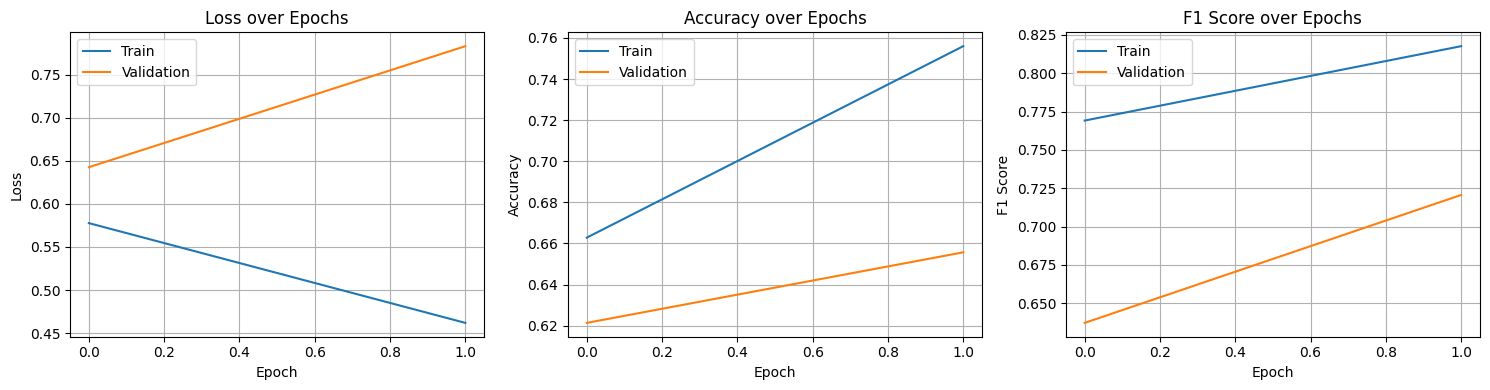

In [16]:
# ===== Plot Training History =====
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()
axes[1].grid(True)

# F1 Score
axes[2].plot(history['train_f1'], label='Train')
axes[2].plot(history['val_f1'], label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 Score over Epochs')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Save Model

Save the trained model for later use or error-correction stage.

In [17]:
# ===== Save Model =====
save_dir = Path("../training/saved_models")
save_dir.mkdir(parents=True, exist_ok=True)

model_path = save_dir / "eegnet_modified_parkinsons.pth"
torch.save({
    'model_state_dict': best_model_state,
    'config': {
        'n_channels': cfg.n_channels,
        'n_classes': cfg.n_classes,
        'n_samples': cfg.n_samples,
    },
    'test_metrics': {
        'accuracy': test_acc,
        'f1_score': test_f1,
        'confusion_matrix': test_cm.tolist(),
    },
    'history': history,
}, model_path)

print(f"Model saved to: {model_path}")
print(f"Test Accuracy: {test_acc:.4f}, Test F1: {test_f1:.4f}")

Model saved to: ..\training\saved_models\eegnet_modified_parkinsons.pth
Test Accuracy: 0.7215, Test F1: 0.7878


# Error Correction